### Visualize SuperPoint + LightGlue feature tracks

In [ ]:
from pathlib import Path
from utils_vis_tracks import (
    build_C_and_C_v2_from_matches_dir,
    print_track_length_stats,
    select_track_by_exact_length,
    get_track_observations,
    print_track_observations,
    plot_feature_track_overlay,
)

root_dir = Path("/home/roger/sat-bundleadjust_github")
aoi_id = "OMA_144"

matches_dir = root_dir / "eval" / "superpoint_matching" / aoi_id

target_track_length = 5
rank = 0  # ATTENTION! change this number to see different tracks e.g. 0, 1, 2, 3 - but they will all have target_track_length
crop_radius = 80
max_images = None

image_paths, C, C_v2 = build_C_and_C_v2_from_matches_dir(
    matches_dir=matches_dir,
    remove_conflicted_tracks=True,
    verbose=False,
)

print_track_length_stats(C)

track_idx = select_track_by_exact_length(
    C=C,
    target_track_length=target_track_length,
    rank=rank,
)

obs = get_track_observations(
    C=C,
    C_v2=C_v2,
    image_paths=image_paths,
    track_idx=track_idx,
)

print(f"Selected track_idx={track_idx}")
print(f"Observed in {len(obs)} images")
print_track_observations(obs)

plot_feature_track_overlay(
    observations=obs,
    track_idx=track_idx,
    crop_radius=crop_radius,
    max_images=max_images,
)

### Visualize epipolar curves v1 - RPC scale for defining alt range

Loaded evaluator functions from: /home/roger/sat-bundleadjust_github/eval/evaluate_rpc_epipolar_consistency_least_similar_pairs.py
Selected AMES bad correspondence
--------------------------------
match_idx: 2740
im_i: 5  image_i: OMA_144_006_RGB.tif
im_j: 15  image_j: OMA_144_017_RGB.tif
kp_i: 1579, kp_j: 1959
point_i: col=568.500, row=1130.500
point_j: col=560.500, row=1074.500
AMES symmetric error from CSV: 1413.105 px
Loaded RPC files:
  OMA_144_001_RGB.tif -> OMA_144_001_RGB.rpc
  OMA_144_002_RGB.tif -> OMA_144_002_RGB.rpc
  OMA_144_003_RGB.tif -> OMA_144_003_RGB.rpc
  OMA_144_004_RGB.tif -> OMA_144_004_RGB.rpc
  OMA_144_005_RGB.tif -> OMA_144_005_RGB.rpc
  OMA_144_006_RGB.tif -> OMA_144_006_RGB.rpc
  OMA_144_007_RGB.tif -> OMA_144_007_RGB.rpc
  OMA_144_008_RGB.tif -> OMA_144_008_RGB.rpc
  OMA_144_009_RGB.tif -> OMA_144_009_RGB.rpc
  OMA_144_010_RGB.tif -> OMA_144_010_RGB.rpc
  OMA_144_011_RGB.tif -> OMA_144_011_RGB.rpc
  OMA_144_012_RGB.tif -> OMA_144_012_RGB.rpc
  OMA_144_013_RG

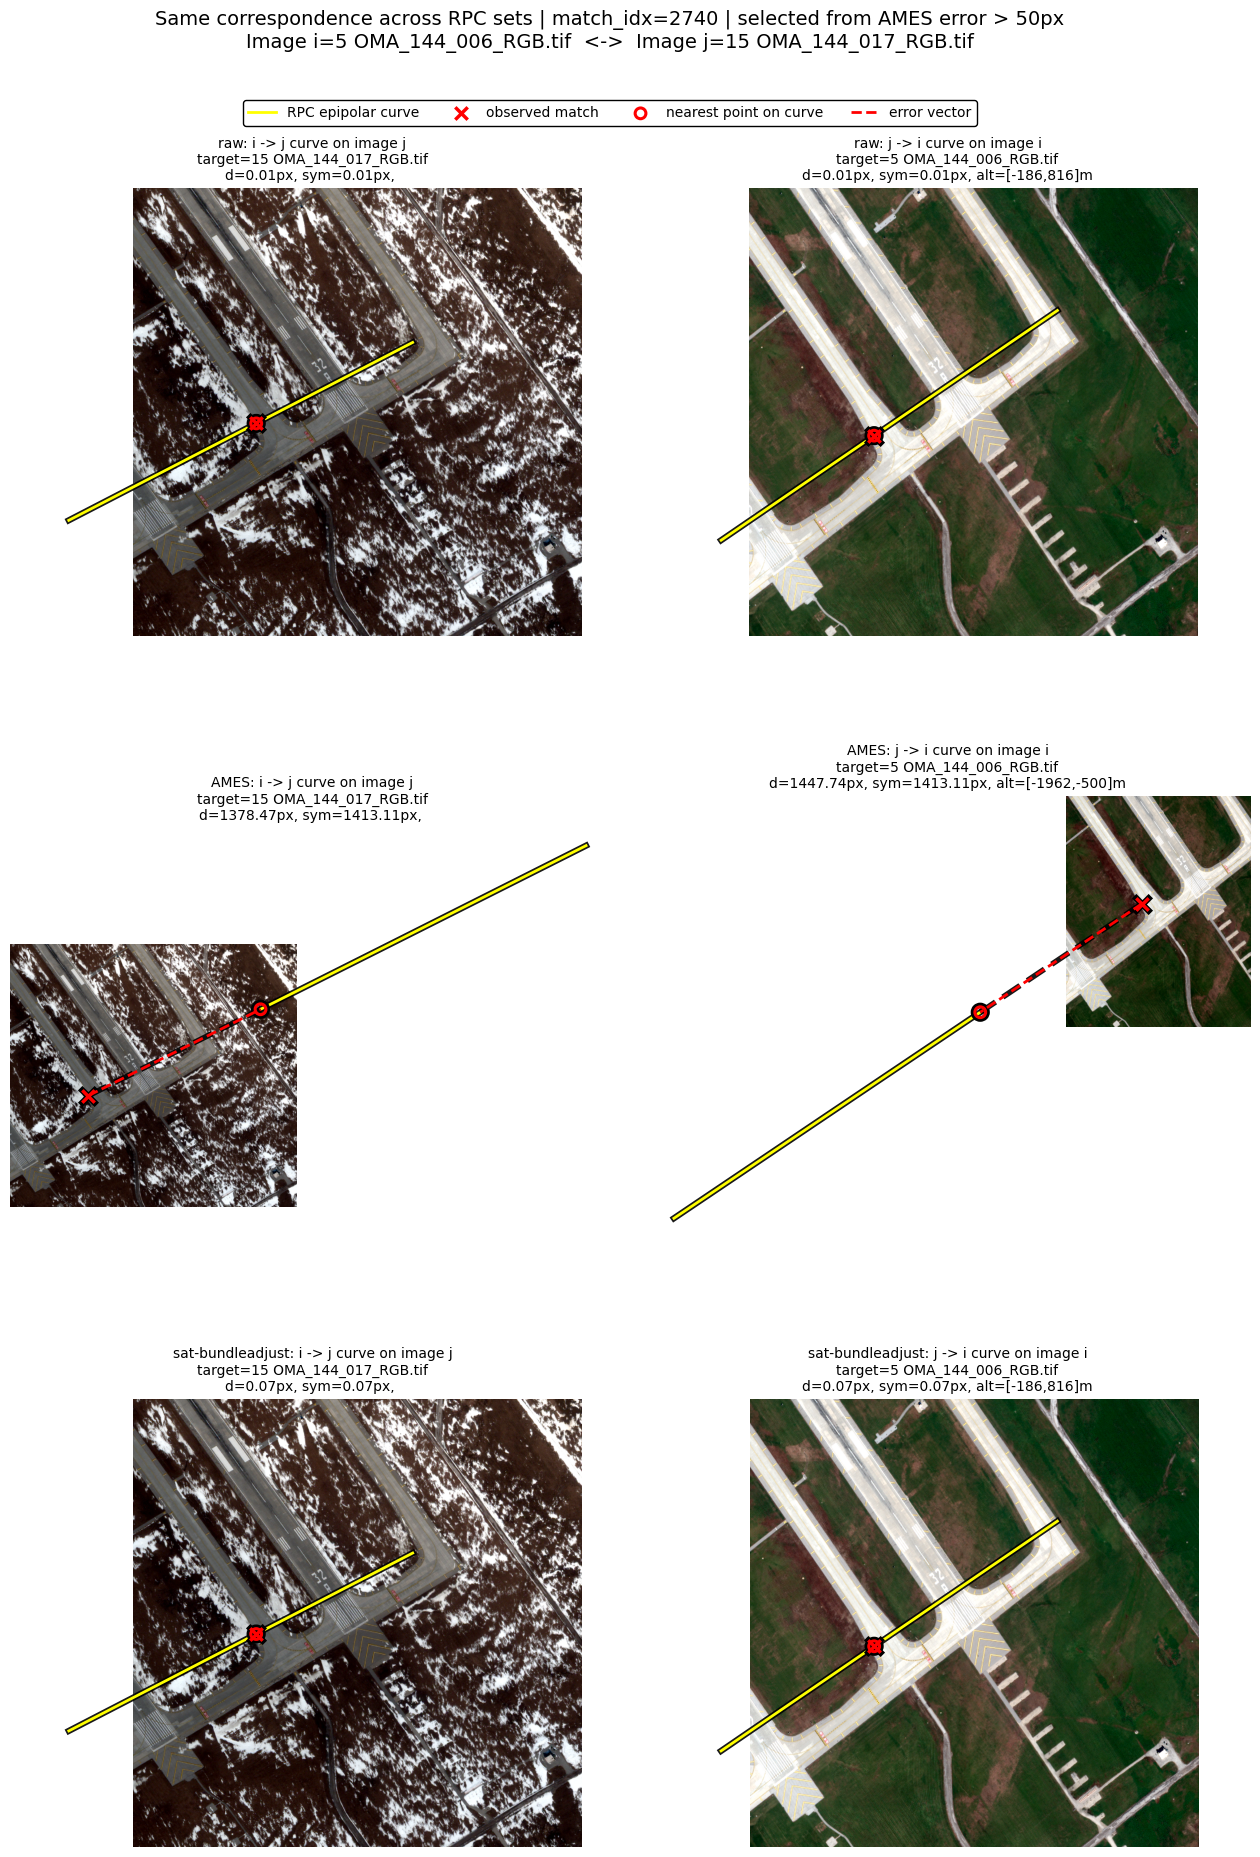

In [17]:
# =============================================================================
# 3x2 epipolar-curve overlay comparison using functions from
# evaluate_rpc_epipolar_consistency_least_similar_pairs.py
#
# Rows:
#   1. raw RPCs
#   2. AMES RPCs
#   3. sat-bundleadjust RPCs
#
# Columns:
#   left:  i -> j epipolar curve overlaid on image j
#   right: j -> i epipolar curve overlaid on image i
# =============================================================================

from pathlib import Path
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import rasterio
except Exception as exc:
    rasterio = None
    print("[warning] rasterio not available:", exc)


# =============================================================================
# USER CONFIG
# =============================================================================

# Path to the evaluator script whose functions we want to reuse.
# If the notebook is in the same directory as the script, this should work.
root_dir="/home/roger/sat-bundleadjust_github"
aoi_id = "OMA_144"
evaluator_py = Path(f"{root_dir}/eval/evaluate_rpc_epipolar_consistency_least_similar_pairs.py")

matches_dir = Path(f"{root_dir}/eval/superpoint_matching/{aoi_id}")

raw_rpc_dir = Path(f"{root_dir}/DATA/data_ready_full/{aoi_id}/rpcs")
ames_rpc_dir = Path(f"/home/roger/ames_ba/outputs_fastest/{aoi_id}/adjusted_rpcs")
sba_rpc_dir = Path(f"{root_dir}/LOGS/exhaustive_eval_full/{aoi_id}/opencv-lightglue-bestpairs-K5/ba_bruteforce/rpcs_adj")

# AMES epipolar output directory from evaluate_rpc_epipolar_consistency_least_similar_pairs.py
ames_epipolar_output_dir = Path(f"{root_dir}/eval/output_rpc_scale/{aoi_id}/ames")
ames_epipolar_errors_csv = ames_epipolar_output_dir / "epipolar_errors.csv"

# Select a bad AMES correspondence
error_threshold_px = 50.0
seed = 0

# Optional: restrict random selection to rows involving one or more suspicious cameras.
# Example:
# BAD_CAMERA_INDICES = [17, 21]
BAD_CAMERA_INDICES = None

# Altitude sweep used only for visualization/recomputation.
# Supported by the evaluator function:
#   "fixed", "center_margin", "rpc_offset_margin", "rpc_scale"
altitude_mode = "rpc_scale"

# Used if altitude_mode == "fixed"
min_alt = None
max_alt = None

# Used if altitude_mode == "center_margin"
center_alt = None

# Used if altitude_mode == "center_margin" or "rpc_offset_margin"
altitude_margin_m = 250.0

n_altitude_samples = 200

# Display options
max_display_size = 1400
crop_around_points = True
crop_margin_px = 800
vmin_percentile = 2
vmax_percentile = 98

curve_linewidth = 2.0
point_size = 80


# =============================================================================
# IMPORT EVALUATOR MODULE
# =============================================================================

if not evaluator_py.exists():
    raise FileNotFoundError(
        f"Could not find evaluator script: {evaluator_py.resolve()}\n"
        "Set evaluator_py to the full path of evaluate_rpc_epipolar_consistency_least_similar_pairs.py"
    )

spec = importlib.util.spec_from_file_location("epi_eval", str(evaluator_py))
epi_eval = importlib.util.module_from_spec(spec)
spec.loader.exec_module(epi_eval)

print(f"Loaded evaluator functions from: {evaluator_py.resolve()}")


# =============================================================================
# SMALL VISUALIZATION HELPERS
# =============================================================================

def point_to_polyline_distance_and_nearest(point, polyline):
    """
    Similar to epi_eval.point_to_polyline_distance, but also returns the nearest
    point on the polyline so we can draw the error vector.
    """
    point = np.asarray(point, dtype=np.float64).reshape(2)
    polyline = np.asarray(polyline, dtype=np.float64)

    if polyline.shape[0] == 0:
        return np.nan, np.array([np.nan, np.nan], dtype=np.float64)

    if polyline.shape[0] == 1:
        return float(np.linalg.norm(point - polyline[0])), polyline[0].copy()

    a = polyline[:-1]
    b = polyline[1:]
    ab = b - a
    ap = point[None, :] - a

    denom = np.sum(ab * ab, axis=1)
    valid = denom > 0

    if not np.any(valid):
        d = np.linalg.norm(point[None, :] - a, axis=1)
        k = int(np.argmin(d))
        return float(d[k]), a[k].copy()

    t = np.zeros(ab.shape[0], dtype=np.float64)
    t[valid] = np.sum(ap[valid] * ab[valid], axis=1) / denom[valid]
    t = np.clip(t, 0.0, 1.0)

    closest = a + t[:, None] * ab
    d = np.linalg.norm(point[None, :] - closest, axis=1)

    k = int(np.argmin(d))
    return float(d[k]), closest[k].copy()


def read_geotiff_crop_centered(image_path, center_xy):
    """
    Read a square crop centered around center_xy = [col, row] in original image pixels.

    Returns:
        img_display
        transform_xy(original_col_row) -> display_col_row
        crop_bounds = (cmin, cmax, rmin, rmax)
    """
    if rasterio is None:
        raise RuntimeError("rasterio is required for GeoTIFF visualization.")

    image_path = Path(image_path)
    center_xy = np.asarray(center_xy, dtype=np.float64).reshape(2)

    with rasterio.open(image_path) as src:
        width = src.width
        height = src.height

        col0 = float(center_xy[0])
        row0 = float(center_xy[1])

        crop_size = int(2 * crop_half_size_px)
        crop_size = max(1, crop_size)

        cmin = int(round(col0 - crop_size / 2))
        rmin = int(round(row0 - crop_size / 2))
        cmax = cmin + crop_size
        rmax = rmin + crop_size

        # Shift the square crop back inside image bounds without changing size,
        # unless the full image dimension is smaller than crop_size.
        if cmin < 0:
            cmax -= cmin
            cmin = 0
        if rmin < 0:
            rmax -= rmin
            rmin = 0
        if cmax > width:
            shift = cmax - width
            cmin -= shift
            cmax = width
        if rmax > height:
            shift = rmax - height
            rmin -= shift
            rmax = height

        cmin = max(0, cmin)
        rmin = max(0, rmin)
        cmax = min(width, cmax)
        rmax = min(height, rmax)

        # If the image itself is smaller than the requested crop in one dimension,
        # this may no longer be square. Pad after reading to keep display square.
        crop_w = max(1, cmax - cmin)
        crop_h = max(1, rmax - rmin)

        out_size = min(max_display_size, max(crop_w, crop_h))
        out_w = int(round(out_size * crop_w / max(crop_w, crop_h)))
        out_h = int(round(out_size * crop_h / max(crop_w, crop_h)))

        out_w = max(1, out_w)
        out_h = max(1, out_h)

        window = rasterio.windows.Window(cmin, rmin, crop_w, crop_h)

        if src.count >= 3:
            arr = src.read(
                [1, 2, 3],
                window=window,
                out_shape=(3, out_h, out_w),
            ).astype(np.float32)
            arr = np.moveaxis(arr, 0, -1)
        else:
            arr = src.read(
                1,
                window=window,
                out_shape=(out_h, out_w),
            ).astype(np.float32)

        valid = np.isfinite(arr)

        if np.any(valid):
            lo = np.percentile(arr[valid], vmin_percentile)
            hi = np.percentile(arr[valid], vmax_percentile)
            if hi <= lo:
                hi = lo + 1.0
            arr = np.clip((arr - lo) / (hi - lo), 0, 1)
        else:
            arr = np.zeros_like(arr, dtype=np.float32)

        # Pad to square display if needed.
        if arr.ndim == 3:
            h, w, ch = arr.shape
            square_size = max(h, w)
            padded = np.zeros((square_size, square_size, ch), dtype=arr.dtype)
            pad_top = (square_size - h) // 2
            pad_left = (square_size - w) // 2
            padded[pad_top:pad_top + h, pad_left:pad_left + w, :] = arr
        else:
            h, w = arr.shape
            square_size = max(h, w)
            padded = np.zeros((square_size, square_size), dtype=arr.dtype)
            pad_top = (square_size - h) // 2
            pad_left = (square_size - w) // 2
            padded[pad_top:pad_top + h, pad_left:pad_left + w] = arr

        scale_x = out_w / crop_w
        scale_y = out_h / crop_h

    def transform_xy(xy):
        xy = np.asarray(xy, dtype=np.float64)
        out = xy.copy()
        out[..., 0] = (out[..., 0] - cmin) * scale_x + pad_left
        out[..., 1] = (out[..., 1] - rmin) * scale_y + pad_top
        return out

    return padded, transform_xy, (cmin, cmax, rmin, rmax)


def plot_curve_panel(
    ax,
    image_path,
    observed_point,
    curve,
    nearest_point,
    title,
):
    points_for_crop = [observed_point]

    if curve is not None and curve.shape[0] > 0:
        points_for_crop.append(curve)

    if nearest_point is not None and np.all(np.isfinite(nearest_point)):
        points_for_crop.append(nearest_point)

    img, tfm = read_geotiff_for_display(image_path, points_for_crop)

    if img.ndim == 2:
        ax.imshow(img, cmap="gray")
    else:
        ax.imshow(img)

    observed_disp = tfm(np.asarray(observed_point, dtype=np.float64))
    curve_disp = tfm(curve) if curve is not None and curve.shape[0] > 0 else np.zeros((0, 2))
    nearest_disp = tfm(np.asarray(nearest_point, dtype=np.float64))

    if curve_disp.shape[0] > 0:
        # Epipolar curve: black outline
        ax.plot(
            curve_disp[:, 0],
            curve_disp[:, 1],
            "-",
            color="black",
            linewidth=curve_linewidth + 2.5,
            alpha=0.9,
            zorder=3,
        )
    
        # Epipolar curve: yellow highlight
        ax.plot(
            curve_disp[:, 0],
            curve_disp[:, 1],
            "-",
            color="yellow",
            linewidth=curve_linewidth,
            alpha=1.0,
            zorder=4,
            label="RPC epipolar curve",
        )
    
    # Observed match point: black outline
    ax.scatter(
        [observed_disp[0]],
        [observed_disp[1]],
        s=point_size * 1.8,
        marker="x",
        color="black",
        linewidths=4.5,
        zorder=5,
    )
    
    # Observed match point: red highlight
    ax.scatter(
        [observed_disp[0]],
        [observed_disp[1]],
        s=point_size,
        marker="x",
        color="red",
        linewidths=2.5,
        zorder=6,
        label="observed match",
    )
    
    if np.all(np.isfinite(nearest_disp)):
        # Nearest curve point: black outline
        ax.scatter(
            [nearest_disp[0]],
            [nearest_disp[1]],
            s=point_size * 1.2,
            marker="o",
            facecolors="none",
            edgecolors="black",
            linewidths=4,
            zorder=5,
        )
    
        # Nearest curve point: red highlight
        ax.scatter(
            [nearest_disp[0]],
            [nearest_disp[1]],
            s=point_size * 0.75,
            marker="o",
            facecolors="none",
            edgecolors="red",
            linewidths=2.2,
            zorder=6,
            label="nearest point on curve",
        )
    
        # Error vector: black outline
        ax.plot(
            [observed_disp[0], nearest_disp[0]],
            [observed_disp[1], nearest_disp[1]],
            "--",
            color="black",
            linewidth=4.0,
            alpha=0.9,
            zorder=5,
        )
    
        # Error vector: red highlight
        ax.plot(
            [observed_disp[0], nearest_disp[0]],
            [observed_disp[1], nearest_disp[1]],
            "--",
            color="red",
            linewidth=2.0,
            alpha=1.0,
            zorder=6,
            label="error vector",
        )

    h, w = img.shape[:2]
    #ax.set_xlim(0, w)
    #ax.set_ylim(h, 0)
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()



# =============================================================================
# LOAD IMAGE PATHS AND SELECT BAD AMES ROW
# =============================================================================

image_paths = epi_eval.load_image_paths(matches_dir)

ames_errors = pd.read_csv(ames_epipolar_errors_csv)

required_cols = {
    "match_idx",
    "im_i",
    "im_j",
    "kp_i",
    "kp_j",
    "col_i",
    "row_i",
    "col_j",
    "row_j",
    "symmetric_epipolar_error_px",
}

missing = required_cols - set(ames_errors.columns)
if missing:
    raise ValueError(f"AMES epipolar_errors.csv missing columns: {sorted(missing)}")

ames_errors["symmetric_epipolar_error_px"] = pd.to_numeric(
    ames_errors["symmetric_epipolar_error_px"],
    errors="coerce",
)

candidates = ames_errors[
    np.isfinite(ames_errors["symmetric_epipolar_error_px"])
    & (ames_errors["symmetric_epipolar_error_px"] > error_threshold_px)
].copy()

if BAD_CAMERA_INDICES is not None:
    bad_set = set(int(x) for x in BAD_CAMERA_INDICES)
    candidates = candidates[
        candidates["im_i"].astype(int).isin(bad_set)
        | candidates["im_j"].astype(int).isin(bad_set)
    ].copy()

if candidates.empty:
    raise RuntimeError(
        f"No AMES correspondences found with symmetric_epipolar_error_px > {error_threshold_px} "
        f"and BAD_CAMERA_INDICES={BAD_CAMERA_INDICES}"
    )

rng = np.random.default_rng(seed)
selected_idx = rng.choice(candidates.index.to_numpy())
selected = candidates.loc[selected_idx]

match_idx = int(selected["match_idx"])
im_i = int(selected["im_i"])
im_j = int(selected["im_j"])
kp_i = int(selected["kp_i"])
kp_j = int(selected["kp_j"])

col_i = float(selected["col_i"])
row_i = float(selected["row_i"])
col_j = float(selected["col_j"])
row_j = float(selected["row_j"])

print("Selected AMES bad correspondence")
print("--------------------------------")
print(f"match_idx: {match_idx}")
print(f"im_i: {im_i}  image_i: {image_paths[im_i].name}")
print(f"im_j: {im_j}  image_j: {image_paths[im_j].name}")
print(f"kp_i: {kp_i}, kp_j: {kp_j}")
print(f"point_i: col={col_i:.3f}, row={row_i:.3f}")
print(f"point_j: col={col_j:.3f}, row={row_j:.3f}")
print(f"AMES symmetric error from CSV: {selected['symmetric_epipolar_error_px']:.3f} px")


# =============================================================================
# LOAD RPC SETS USING EVALUATOR FUNCTION
# =============================================================================

rpc_sets = {
    "raw": raw_rpc_dir,
    "AMES": ames_rpc_dir,
    "sat-bundleadjust": sba_rpc_dir,
}

loaded = {}

for name, rpc_dir in rpc_sets.items():
    rpcs = epi_eval.load_rpcs_for_images(rpc_dir, image_paths)

    rpc_file_i = epi_eval.find_rpc_file_for_image(rpc_dir, image_paths[im_i])
    rpc_file_j = epi_eval.find_rpc_file_for_image(rpc_dir, image_paths[im_j])

    loaded[name] = {
        "rpcs": rpcs,
        "rpc_file_i": rpc_file_i,
        "rpc_file_j": rpc_file_j,
    }

    print(f"\n{name} RPC files:")
    print(f"  image_i -> {rpc_file_i.name}")
    print(f"  image_j -> {rpc_file_j.name}")
    print(
        f"  image_i alt_offset={epi_eval.rpc_alt_offset(rpcs[im_i]):.3f}, "
        f"alt_scale={epi_eval.rpc_alt_scale(rpcs[im_i]):.3f}"
    )
    print(
        f"  image_j alt_offset={epi_eval.rpc_alt_offset(rpcs[im_j]):.3f}, "
        f"alt_scale={epi_eval.rpc_alt_scale(rpcs[im_j]):.3f}"
    )


# =============================================================================
# COMPUTE CURVES USING EVALUATOR FUNCTIONS
# =============================================================================

curves = {}

for name, info in loaded.items():
    rpcs = info["rpcs"]

    rpc_i = rpcs[im_i]
    rpc_j = rpcs[im_j]

    alt_min, alt_max = epi_eval.altitude_range_for_pair(
        rpc_i,
        rpc_j,
        mode=altitude_mode,
        fixed_min_alt=min_alt,
        fixed_max_alt=max_alt,
        fixed_center_alt=center_alt,
        fixed_margin_m=altitude_margin_m,
    )

    if alt_max <= alt_min:
        raise ValueError(f"{name}: invalid altitude range [{alt_min}, {alt_max}]")

    altitudes = np.linspace(alt_min, alt_max, n_altitude_samples)

    curve_i_to_j = epi_eval.epipolar_curve_rpc_to_rpc(
        source_rpc=rpc_i,
        target_rpc=rpc_j,
        source_col=col_i,
        source_row=row_i,
        altitudes=altitudes,
    )

    curve_j_to_i = epi_eval.epipolar_curve_rpc_to_rpc(
        source_rpc=rpc_j,
        target_rpc=rpc_i,
        source_col=col_j,
        source_row=row_j,
        altitudes=altitudes,
    )

    # Reuse evaluator distance for consistency.
    d_i_to_j = epi_eval.point_to_polyline_distance(
        np.asarray([col_j, row_j], dtype=np.float64),
        curve_i_to_j,
    )

    d_j_to_i = epi_eval.point_to_polyline_distance(
        np.asarray([col_i, row_i], dtype=np.float64),
        curve_j_to_i,
    )

    # Local helper also returns nearest point for visualization.
    d_i_to_j_nearest, nearest_i_to_j = point_to_polyline_distance_and_nearest(
        np.asarray([col_j, row_j], dtype=np.float64),
        curve_i_to_j,
    )

    d_j_to_i_nearest, nearest_j_to_i = point_to_polyline_distance_and_nearest(
        np.asarray([col_i, row_i], dtype=np.float64),
        curve_j_to_i,
    )

    # Sanity check: both distance implementations should agree.
    if np.isfinite(d_i_to_j) and np.isfinite(d_i_to_j_nearest):
        assert abs(d_i_to_j - d_i_to_j_nearest) < 1e-6

    if np.isfinite(d_j_to_i) and np.isfinite(d_j_to_i_nearest):
        assert abs(d_j_to_i - d_j_to_i_nearest) < 1e-6

    sym = 0.5 * (d_i_to_j + d_j_to_i)

    curves[name] = {
        "alt_min": alt_min,
        "alt_max": alt_max,
        "curve_i_to_j": curve_i_to_j,
        "curve_j_to_i": curve_j_to_i,
        "d_i_to_j": d_i_to_j,
        "d_j_to_i": d_j_to_i,
        "sym": sym,
        "nearest_i_to_j": nearest_i_to_j,
        "nearest_j_to_i": nearest_j_to_i,
        "length_i_to_j": epi_eval.polyline_length(curve_i_to_j),
        "length_j_to_i": epi_eval.polyline_length(curve_j_to_i),
    }

    print(f"\n{name} recomputed epipolar errors:")
    print(f"  altitude range: [{alt_min:.3f}, {alt_max:.3f}] m")
    print(f"  valid samples i->j: {curve_i_to_j.shape[0]}")
    print(f"  valid samples j->i: {curve_j_to_i.shape[0]}")
    print(f"  curve length i->j: {curves[name]['length_i_to_j']:.3f} px")
    print(f"  curve length j->i: {curves[name]['length_j_to_i']:.3f} px")
    print(f"  d_i_to_j: {d_i_to_j:.3f} px")
    print(f"  d_j_to_i: {d_j_to_i:.3f} px")
    print(f"  symmetric: {sym:.3f} px")


# =============================================================================
# PLOT 3x2
# =============================================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(16, 21),
    constrained_layout=False,
)

row_names = ["raw", "AMES", "sat-bundleadjust"]

for row_idx, name in enumerate(row_names):
    c = curves[name]

    title_left = (
        f"{name}: i -> j curve on image j\n"
        f"target={im_j} {image_paths[im_j].name}\n"
        f"d={c['d_i_to_j']:.2f}px, sym={c['sym']:.2f}px, "
        #f"alt=[{c['alt_min']:.0f},{c['alt_max']:.0f}]m"
    )

    plot_curve_panel(
        ax=axes[row_idx, 0],
        image_path=image_paths[im_j],
        observed_point=np.asarray([col_j, row_j], dtype=np.float64),
        curve=c["curve_i_to_j"],
        nearest_point=c["nearest_i_to_j"],
        title=title_left,
    )

    title_right = (
        f"{name}: j -> i curve on image i\n"
        f"target={im_i} {image_paths[im_i].name}\n"
        f"d={c['d_j_to_i']:.2f}px, sym={c['sym']:.2f}px, "
        f"alt=[{c['alt_min']:.0f},{c['alt_max']:.0f}]m"
    )

    plot_curve_panel(
        ax=axes[row_idx, 1],
        image_path=image_paths[im_i],
        observed_point=np.asarray([col_i, row_i], dtype=np.float64),
        curve=c["curve_j_to_i"],
        nearest_point=c["nearest_j_to_i"],
        title=title_right,
    )

#handles, labels = axes[0, 0].get_legend_handles_labels()
#if handles:
#    fig.legend(handles, labels, loc="upper center", ncol=3)

# Main title
fig.suptitle(
    (
        f"Same correspondence across RPC sets | match_idx={match_idx} | "
        f"selected from AMES error > {error_threshold_px:g}px\n"
        f"Image i={im_i} {image_paths[im_i].name}  <->  "
        f"Image j={im_j} {image_paths[im_j].name}"
    ),
    fontsize=14,
    y=0.985,
)

# Legend below title, outside all axes
handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.945),
        ncol=4,
        frameon=True,
        facecolor="white",
        framealpha=1.0,
        edgecolor="black",
        fontsize=10,
    )

# Reserve space at top for title + legend
fig.subplots_adjust(
    top=0.90,
    hspace=0.35,
    wspace=0.05,
)

output_png = Path("epipolar_curve_overlay_v1_alt_range_from_rpc_scale.png")
fig.savefig(output_png, dpi=200, bbox_inches="tight")
print(f"Saved plot to: {output_png.resolve()}")

plt.show()

### Visualize epipolar curves v1 - Predefined alt range

Loaded evaluator functions from: /home/roger/sat-bundleadjust_github/eval/evaluate_rpc_epipolar_consistency_least_similar_pairs.py
Selected correspondence
-----------------------
criterion: SBA error < 1 px, maximize AMES error
selected_rank: 0
match_idx: 10651
im_i: 14  image_i: OMA_144_016_RGB.tif
im_j: 16  image_j: OMA_144_018_RGB.tif
kp_i: 372, kp_j: 2192
point_i: col=164.500, row=1800.500
point_j: col=188.500, row=1944.500
raw CSV error:  0.308 px
AMES CSV error: 4.446 px
SBA CSV error:  0.073 px
candidate count: 8737
Loaded RPC files:
  OMA_144_001_RGB.tif -> OMA_144_001_RGB.rpc
  OMA_144_002_RGB.tif -> OMA_144_002_RGB.rpc
  OMA_144_003_RGB.tif -> OMA_144_003_RGB.rpc
  OMA_144_004_RGB.tif -> OMA_144_004_RGB.rpc
  OMA_144_005_RGB.tif -> OMA_144_005_RGB.rpc
  OMA_144_006_RGB.tif -> OMA_144_006_RGB.rpc
  OMA_144_007_RGB.tif -> OMA_144_007_RGB.rpc
  OMA_144_008_RGB.tif -> OMA_144_008_RGB.rpc
  OMA_144_009_RGB.tif -> OMA_144_009_RGB.rpc
  OMA_144_010_RGB.tif -> OMA_144_010_RGB.rpc
  O

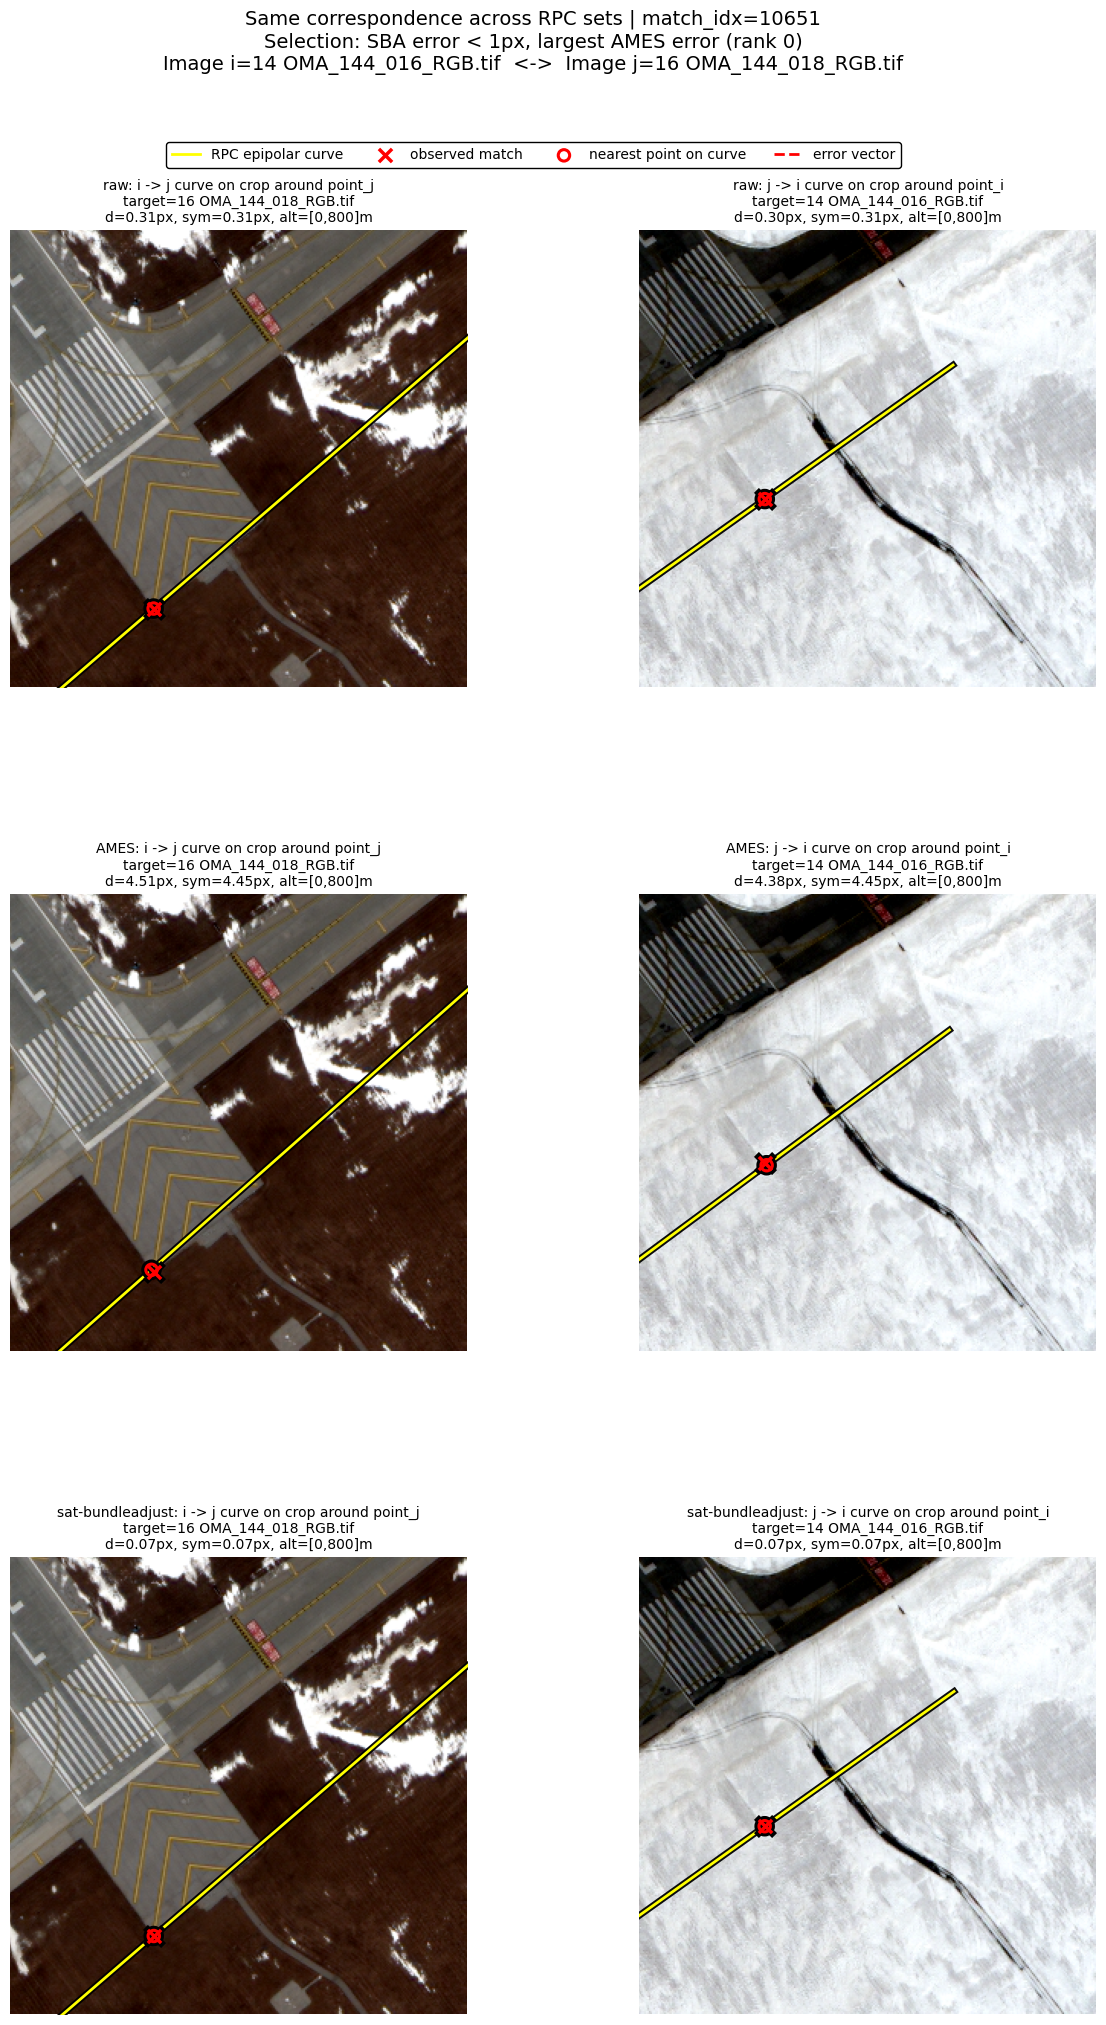

In [16]:
# =============================================================================
# 3x2 epipolar-curve overlay comparison using functions from
# evaluate_rpc_epipolar_consistency_least_similar_pairs.py
#
# Rows:
#   1. raw RPCs
#   2. AMES RPCs
#   3. sat-bundleadjust RPCs
#
# Columns:
#   left:  i -> j epipolar curve overlaid on image j
#   right: j -> i epipolar curve overlaid on image i
# =============================================================================

from pathlib import Path
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import rasterio
except Exception as exc:
    rasterio = None
    print("[warning] rasterio not available:", exc)


# =============================================================================
# USER CONFIG
# =============================================================================

# Path to the evaluator script whose functions we want to reuse.
# If the notebook is in the same directory as the script, this should work.
root_dir="/home/roger/sat-bundleadjust_github"
aoi_id = "OMA_144"
evaluator_py = Path(f"{root_dir}/eval/evaluate_rpc_epipolar_consistency_least_similar_pairs.py")

matches_dir = Path(f"{root_dir}/eval/superpoint_matching/{aoi_id}")

raw_rpc_dir = Path(f"{root_dir}/DATA/data_ready_full/{aoi_id}/rpcs")
ames_rpc_dir = Path(f"/home/roger/ames_ba/outputs_fastest/{aoi_id}/adjusted_rpcs")
sba_rpc_dir = Path(f"{root_dir}/LOGS/exhaustive_eval_full/{aoi_id}/opencv-lightglue-bestpairs-K5/ba_bruteforce/rpcs_adj")

# AMES epipolar output directory from evaluate_rpc_epipolar_consistency_least_similar_pairs.py
raw_epipolar_output_dir = Path(f"{root_dir}/eval/output_alt_fixed_0-800/{aoi_id}/raw_rpcs")
ames_epipolar_output_dir = Path(f"{root_dir}/eval/output_alt_fixed_0-800/{aoi_id}/ames")
sba_epipolar_output_dir = Path(f"{root_dir}/eval/output_alt_fixed_0-800/{aoi_id}/sat-bundleadjust")

raw_epipolar_errors_csv = raw_epipolar_output_dir / "epipolar_errors.csv"
ames_epipolar_errors_csv = ames_epipolar_output_dir / "epipolar_errors.csv"
sba_epipolar_errors_csv = sba_epipolar_output_dir / "epipolar_errors.csv"

# Selection criterion
sba_good_threshold_px = 1.0

# Optional: restrict to rows involving one or more suspicious AMES cameras.
# Example:
# BAD_CAMERA_INDICES = [17, 21]
BAD_CAMERA_INDICES = None

# Optional: choose rank among worst AMES cases after filtering.
# rank=0 means largest AMES error.
# rank=1 means second-largest AMES error.
selected_rank = 0

# Altitude sweep used for visualization/recomputation.
# Supported:
#   "fixed", "center_margin", "rpc_offset_margin", "rpc_scale"
altitude_mode = "fixed"

# Used if altitude_mode == "fixed"
min_alt = 0
max_alt = 800

# Used if altitude_mode == "center_margin"
center_alt = None

# Used if altitude_mode == "center_margin" or "rpc_offset_margin"
altitude_margin_m = 250.0

n_altitude_samples = 200

# Crop display
crop_half_size_px = 300       # original-image pixels around GT/observed keypoint
max_display_size = 300        # max displayed crop size
vmin_percentile = 2
vmax_percentile = 98

# Styling
curve_linewidth = 2.0
point_size = 90

output_png = Path("epipolar_curve_overlay_v2_alt_range_predefined_sba_good_ames_bad_crop.png")


# =============================================================================
# IMPORT EVALUATOR MODULE
# =============================================================================

if not evaluator_py.exists():
    raise FileNotFoundError(
        f"Could not find evaluator script: {evaluator_py.resolve()}\n"
        "Set evaluator_py to the full path of evaluate_rpc_epipolar_consistency_least_similar_pairs.py"
    )

spec = importlib.util.spec_from_file_location("epi_eval", str(evaluator_py))
epi_eval = importlib.util.module_from_spec(spec)
spec.loader.exec_module(epi_eval)

print(f"Loaded evaluator functions from: {evaluator_py.resolve()}")


# =============================================================================
# LOCAL VISUALIZATION HELPERS
# =============================================================================

def point_to_polyline_distance_and_nearest(point, polyline):
    """
    Same distance as epi_eval.point_to_polyline_distance, but also returns
    the nearest point on the polyline so the error vector can be drawn.
    """
    point = np.asarray(point, dtype=np.float64).reshape(2)
    polyline = np.asarray(polyline, dtype=np.float64)

    if polyline.shape[0] == 0:
        return np.nan, np.array([np.nan, np.nan], dtype=np.float64)

    if polyline.shape[0] == 1:
        return float(np.linalg.norm(point - polyline[0])), polyline[0].copy()

    a = polyline[:-1]
    b = polyline[1:]
    ab = b - a
    ap = point[None, :] - a

    denom = np.sum(ab * ab, axis=1)
    valid = denom > 0

    if not np.any(valid):
        d = np.linalg.norm(point[None, :] - a, axis=1)
        k = int(np.argmin(d))
        return float(d[k]), a[k].copy()

    t = np.zeros(ab.shape[0], dtype=np.float64)
    t[valid] = np.sum(ap[valid] * ab[valid], axis=1) / denom[valid]
    t = np.clip(t, 0.0, 1.0)

    closest = a + t[:, None] * ab
    d = np.linalg.norm(point[None, :] - closest, axis=1)

    k = int(np.argmin(d))
    return float(d[k]), closest[k].copy()


def read_geotiff_crop_centered(image_path, center_xy):
    """
    Read a square crop centered around center_xy = [col, row] in original image pixels.

    Returns:
        img_display
        transform_xy(original_col_row) -> display_col_row
        crop_bounds = (cmin, cmax, rmin, rmax)
    """
    if rasterio is None:
        raise RuntimeError("rasterio is required for GeoTIFF visualization.")

    image_path = Path(image_path)
    center_xy = np.asarray(center_xy, dtype=np.float64).reshape(2)

    with rasterio.open(image_path) as src:
        width = src.width
        height = src.height

        col0 = float(center_xy[0])
        row0 = float(center_xy[1])

        crop_size = int(2 * crop_half_size_px)
        crop_size = max(1, crop_size)

        cmin = int(round(col0 - crop_size / 2))
        rmin = int(round(row0 - crop_size / 2))
        cmax = cmin + crop_size
        rmax = rmin + crop_size

        # Shift the square crop back inside image bounds without changing size,
        # unless the full image dimension is smaller than crop_size.
        if cmin < 0:
            cmax -= cmin
            cmin = 0
        if rmin < 0:
            rmax -= rmin
            rmin = 0
        if cmax > width:
            shift = cmax - width
            cmin -= shift
            cmax = width
        if rmax > height:
            shift = rmax - height
            rmin -= shift
            rmax = height

        cmin = max(0, cmin)
        rmin = max(0, rmin)
        cmax = min(width, cmax)
        rmax = min(height, rmax)

        # If the image itself is smaller than the requested crop in one dimension,
        # this may no longer be square. Pad after reading to keep display square.
        crop_w = max(1, cmax - cmin)
        crop_h = max(1, rmax - rmin)

        out_size = min(max_display_size, max(crop_w, crop_h))
        out_w = int(round(out_size * crop_w / max(crop_w, crop_h)))
        out_h = int(round(out_size * crop_h / max(crop_w, crop_h)))

        out_w = max(1, out_w)
        out_h = max(1, out_h)

        window = rasterio.windows.Window(cmin, rmin, crop_w, crop_h)

        if src.count >= 3:
            arr = src.read(
                [1, 2, 3],
                window=window,
                out_shape=(3, out_h, out_w),
            ).astype(np.float32)
            arr = np.moveaxis(arr, 0, -1)
        else:
            arr = src.read(
                1,
                window=window,
                out_shape=(out_h, out_w),
            ).astype(np.float32)

        valid = np.isfinite(arr)

        if np.any(valid):
            lo = np.percentile(arr[valid], vmin_percentile)
            hi = np.percentile(arr[valid], vmax_percentile)
            if hi <= lo:
                hi = lo + 1.0
            arr = np.clip((arr - lo) / (hi - lo), 0, 1)
        else:
            arr = np.zeros_like(arr, dtype=np.float32)

        # Pad to square display if needed.
        if arr.ndim == 3:
            h, w, ch = arr.shape
            square_size = max(h, w)
            padded = np.zeros((square_size, square_size, ch), dtype=arr.dtype)
            pad_top = (square_size - h) // 2
            pad_left = (square_size - w) // 2
            padded[pad_top:pad_top + h, pad_left:pad_left + w, :] = arr
        else:
            h, w = arr.shape
            square_size = max(h, w)
            padded = np.zeros((square_size, square_size), dtype=arr.dtype)
            pad_top = (square_size - h) // 2
            pad_left = (square_size - w) // 2
            padded[pad_top:pad_top + h, pad_left:pad_left + w] = arr

        scale_x = out_w / crop_w
        scale_y = out_h / crop_h

    def transform_xy(xy):
        xy = np.asarray(xy, dtype=np.float64)
        out = xy.copy()
        out[..., 0] = (out[..., 0] - cmin) * scale_x + pad_left
        out[..., 1] = (out[..., 1] - rmin) * scale_y + pad_top
        return out

    return padded, transform_xy, (cmin, cmax, rmin, rmax)


def plot_curve_panel(
    ax,
    image_path,
    crop_center_point,
    observed_point,
    curve,
    nearest_point,
    title,
):
    img, tfm, crop_bounds = read_geotiff_crop_centered(
        image_path=image_path,
        center_xy=crop_center_point,
    )

    if img.ndim == 2:
        ax.imshow(img, cmap="gray")
    else:
        ax.imshow(img)

    observed_disp = tfm(np.asarray(observed_point, dtype=np.float64))
    nearest_disp = tfm(np.asarray(nearest_point, dtype=np.float64))
    curve_disp = tfm(curve) if curve is not None and curve.shape[0] > 0 else np.zeros((0, 2))

    h, w = img.shape[:2]

    # Draw the full transformed curve. Parts outside the crop are clipped by axes.
    if curve_disp.shape[0] > 0:
        # Epipolar curve black outline
        ax.plot(
            curve_disp[:, 0],
            curve_disp[:, 1],
            "-",
            color="black",
            linewidth=curve_linewidth + 2.8,
            alpha=0.95,
            zorder=3,
            clip_on=True,
        )

        # Epipolar curve yellow highlight
        ax.plot(
            curve_disp[:, 0],
            curve_disp[:, 1],
            "-",
            color="yellow",
            linewidth=curve_linewidth,
            alpha=1.0,
            zorder=4,
            clip_on=True,
            label="RPC epipolar curve",
        )

    # Observed keypoint black outline
    ax.scatter(
        [observed_disp[0]],
        [observed_disp[1]],
        s=point_size * 1.9,
        marker="x",
        color="black",
        linewidths=5.0,
        zorder=7,
        clip_on=True,
    )

    # Observed keypoint red highlight
    ax.scatter(
        [observed_disp[0]],
        [observed_disp[1]],
        s=point_size,
        marker="x",
        color="red",
        linewidths=2.5,
        zorder=8,
        clip_on=True,
        label="observed match",
    )

    if np.all(np.isfinite(nearest_disp)):
        # Nearest point black outline
        ax.scatter(
            [nearest_disp[0]],
            [nearest_disp[1]],
            s=point_size * 1.25,
            marker="o",
            facecolors="none",
            edgecolors="black",
            linewidths=4.2,
            zorder=7,
            clip_on=True,
        )

        # Nearest point red highlight
        ax.scatter(
            [nearest_disp[0]],
            [nearest_disp[1]],
            s=point_size * 0.75,
            marker="o",
            facecolors="none",
            edgecolors="red",
            linewidths=2.2,
            zorder=8,
            clip_on=True,
            label="nearest point on curve",
        )

        # Error vector black outline
        ax.plot(
            [observed_disp[0], nearest_disp[0]],
            [observed_disp[1], nearest_disp[1]],
            "--",
            color="black",
            linewidth=4.2,
            alpha=0.95,
            zorder=5,
            clip_on=True,
        )

        # Error vector red highlight
        ax.plot(
            [observed_disp[0], nearest_disp[0]],
            [observed_disp[1], nearest_disp[1]],
            "--",
            color="red",
            linewidth=2.0,
            alpha=1.0,
            zorder=6,
            clip_on=True,
            label="error vector",
        )

    h, w = img.shape[:2]
    side = max(h, w)
    
    ax.set_xlim(0, side)
    ax.set_ylim(side, 0)
    ax.set_aspect("equal", adjustable="box")
    ax.set_box_aspect(1)
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()


# =============================================================================
# LOAD IMAGE PATHS AND ERROR CSVs
# =============================================================================

image_paths = epi_eval.load_image_paths(matches_dir)

raw_df = pd.read_csv(raw_epipolar_errors_csv)
ames_df = pd.read_csv(ames_epipolar_errors_csv)
sba_df = pd.read_csv(sba_epipolar_errors_csv)

required_cols = {
    "match_idx",
    "im_i",
    "im_j",
    "kp_i",
    "kp_j",
    "col_i",
    "row_i",
    "col_j",
    "row_j",
    "symmetric_epipolar_error_px",
}

for name, df in [("raw", raw_df), ("AMES", ames_df), ("sat-bundleadjust", sba_df)]:
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"{name} epipolar_errors.csv missing columns: {sorted(missing)}")

    df["symmetric_epipolar_error_px"] = pd.to_numeric(
        df["symmetric_epipolar_error_px"],
        errors="coerce",
    )

# Keep only one row per match_idx in each output.
# This assumes match_idx is stable across runs, which it should be if all runs use the same matches_dir
# and selected/evaluated rows are comparable.
raw_small = raw_df[list(required_cols)].copy()
ames_small = ames_df[list(required_cols)].copy()
sba_small = sba_df[list(required_cols)].copy()

raw_small = raw_small.rename(columns={"symmetric_epipolar_error_px": "raw_error_px"})
ames_small = ames_small.rename(columns={"symmetric_epipolar_error_px": "ames_error_px"})
sba_small = sba_small.rename(columns={"symmetric_epipolar_error_px": "sba_error_px"})

# Merge on match_idx and geometry columns to guarantee same correspondence.
merge_keys = [
    "match_idx",
    "im_i",
    "im_j",
    "kp_i",
    "kp_j",
    "col_i",
    "row_i",
    "col_j",
    "row_j",
]

merged = sba_small.merge(
    ames_small[merge_keys + ["ames_error_px"]],
    on=merge_keys,
    how="inner",
).merge(
    raw_small[merge_keys + ["raw_error_px"]],
    on=merge_keys,
    how="left",
)

merged = merged[
    np.isfinite(merged["sba_error_px"])
    & np.isfinite(merged["ames_error_px"])
].copy()

candidates = merged[merged["sba_error_px"] < sba_good_threshold_px].copy()

if BAD_CAMERA_INDICES is not None:
    bad_set = set(int(x) for x in BAD_CAMERA_INDICES)
    candidates = candidates[
        candidates["im_i"].astype(int).isin(bad_set)
        | candidates["im_j"].astype(int).isin(bad_set)
    ].copy()

if candidates.empty:
    raise RuntimeError(
        f"No correspondences found with SBA error < {sba_good_threshold_px} px "
        f"and BAD_CAMERA_INDICES={BAD_CAMERA_INDICES}"
    )

candidates = candidates.sort_values("ames_error_px", ascending=False).reset_index(drop=True)

if selected_rank >= len(candidates):
    raise ValueError(
        f"selected_rank={selected_rank} but only {len(candidates)} candidates are available"
    )

selected = candidates.iloc[selected_rank]

match_idx = int(selected["match_idx"])
im_i = int(selected["im_i"])
im_j = int(selected["im_j"])
kp_i = int(selected["kp_i"])
kp_j = int(selected["kp_j"])

col_i = float(selected["col_i"])
row_i = float(selected["row_i"])
col_j = float(selected["col_j"])
row_j = float(selected["row_j"])

print("Selected correspondence")
print("-----------------------")
print(f"criterion: SBA error < {sba_good_threshold_px:g} px, maximize AMES error")
print(f"selected_rank: {selected_rank}")
print(f"match_idx: {match_idx}")
print(f"im_i: {im_i}  image_i: {image_paths[im_i].name}")
print(f"im_j: {im_j}  image_j: {image_paths[im_j].name}")
print(f"kp_i: {kp_i}, kp_j: {kp_j}")
print(f"point_i: col={col_i:.3f}, row={row_i:.3f}")
print(f"point_j: col={col_j:.3f}, row={row_j:.3f}")
print(f"raw CSV error:  {selected.get('raw_error_px', np.nan):.3f} px")
print(f"AMES CSV error: {selected['ames_error_px']:.3f} px")
print(f"SBA CSV error:  {selected['sba_error_px']:.3f} px")
print(f"candidate count: {len(candidates)}")


# =============================================================================
# LOAD RPC SETS USING EVALUATOR FUNCTIONS
# =============================================================================

rpc_sets = {
    "raw": raw_rpc_dir,
    "AMES": ames_rpc_dir,
    "sat-bundleadjust": sba_rpc_dir,
}

loaded = {}

for name, rpc_dir in rpc_sets.items():
    rpcs = epi_eval.load_rpcs_for_images(rpc_dir, image_paths)

    rpc_file_i = epi_eval.find_rpc_file_for_image(rpc_dir, image_paths[im_i])
    rpc_file_j = epi_eval.find_rpc_file_for_image(rpc_dir, image_paths[im_j])

    loaded[name] = {
        "rpcs": rpcs,
        "rpc_file_i": rpc_file_i,
        "rpc_file_j": rpc_file_j,
    }

    print(f"\n{name} RPC files:")
    print(f"  image_i -> {rpc_file_i.name}")
    print(f"  image_j -> {rpc_file_j.name}")
    print(
        f"  image_i alt_offset={epi_eval.rpc_alt_offset(rpcs[im_i]):.3f}, "
        f"alt_scale={epi_eval.rpc_alt_scale(rpcs[im_i]):.3f}"
    )
    print(
        f"  image_j alt_offset={epi_eval.rpc_alt_offset(rpcs[im_j]):.3f}, "
        f"alt_scale={epi_eval.rpc_alt_scale(rpcs[im_j]):.3f}"
    )


# =============================================================================
# COMPUTE CURVES USING EVALUATOR FUNCTIONS
# =============================================================================

curves = {}

for name, info in loaded.items():
    rpcs = info["rpcs"]

    rpc_i = rpcs[im_i]
    rpc_j = rpcs[im_j]

    alt_min, alt_max = epi_eval.altitude_range_for_pair(
        rpc_i,
        rpc_j,
        mode=altitude_mode,
        fixed_min_alt=min_alt,
        fixed_max_alt=max_alt,
        fixed_center_alt=center_alt,
        fixed_margin_m=altitude_margin_m,
    )

    if alt_max <= alt_min:
        raise ValueError(f"{name}: invalid altitude range [{alt_min}, {alt_max}]")

    altitudes = np.linspace(alt_min, alt_max, n_altitude_samples)

    curve_i_to_j = epi_eval.epipolar_curve_rpc_to_rpc(
        source_rpc=rpc_i,
        target_rpc=rpc_j,
        source_col=col_i,
        source_row=row_i,
        altitudes=altitudes,
    )

    curve_j_to_i = epi_eval.epipolar_curve_rpc_to_rpc(
        source_rpc=rpc_j,
        target_rpc=rpc_i,
        source_col=col_j,
        source_row=row_j,
        altitudes=altitudes,
    )

    d_i_to_j = epi_eval.point_to_polyline_distance(
        np.asarray([col_j, row_j], dtype=np.float64),
        curve_i_to_j,
    )

    d_j_to_i = epi_eval.point_to_polyline_distance(
        np.asarray([col_i, row_i], dtype=np.float64),
        curve_j_to_i,
    )

    _, nearest_i_to_j = point_to_polyline_distance_and_nearest(
        np.asarray([col_j, row_j], dtype=np.float64),
        curve_i_to_j,
    )

    _, nearest_j_to_i = point_to_polyline_distance_and_nearest(
        np.asarray([col_i, row_i], dtype=np.float64),
        curve_j_to_i,
    )

    sym = 0.5 * (d_i_to_j + d_j_to_i)

    curves[name] = {
        "alt_min": alt_min,
        "alt_max": alt_max,
        "curve_i_to_j": curve_i_to_j,
        "curve_j_to_i": curve_j_to_i,
        "d_i_to_j": d_i_to_j,
        "d_j_to_i": d_j_to_i,
        "sym": sym,
        "nearest_i_to_j": nearest_i_to_j,
        "nearest_j_to_i": nearest_j_to_i,
        "length_i_to_j": epi_eval.polyline_length(curve_i_to_j),
        "length_j_to_i": epi_eval.polyline_length(curve_j_to_i),
    }

    print(f"\n{name} recomputed epipolar errors:")
    print(f"  altitude range: [{alt_min:.3f}, {alt_max:.3f}] m")
    print(f"  valid samples i->j: {curve_i_to_j.shape[0]}")
    print(f"  valid samples j->i: {curve_j_to_i.shape[0]}")
    print(f"  curve length i->j: {curves[name]['length_i_to_j']:.3f} px")
    print(f"  curve length j->i: {curves[name]['length_j_to_i']:.3f} px")
    print(f"  d_i_to_j: {d_i_to_j:.3f} px")
    print(f"  d_j_to_i: {d_j_to_i:.3f} px")
    print(f"  symmetric: {sym:.3f} px")


# =============================================================================
# PLOT 3x2 CROPS CENTERED ON OBSERVED MATCH POINTS
# =============================================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(16, 21),
    constrained_layout=False,
)

row_names = ["raw", "AMES", "sat-bundleadjust"]

for row_idx, name in enumerate(row_names):
    c = curves[name]

    title_left = (
        f"{name}: i -> j curve on crop around point_j\n"
        f"target={im_j} {image_paths[im_j].name}\n"
        f"d={c['d_i_to_j']:.2f}px, sym={c['sym']:.2f}px, "
        f"alt=[{c['alt_min']:.0f},{c['alt_max']:.0f}]m"
    )

    plot_curve_panel(
        ax=axes[row_idx, 0],
        image_path=image_paths[im_j],
        crop_center_point=np.asarray([col_j, row_j], dtype=np.float64),
        observed_point=np.asarray([col_j, row_j], dtype=np.float64),
        curve=c["curve_i_to_j"],
        nearest_point=c["nearest_i_to_j"],
        title=title_left,
    )

    title_right = (
        f"{name}: j -> i curve on crop around point_i\n"
        f"target={im_i} {image_paths[im_i].name}\n"
        f"d={c['d_j_to_i']:.2f}px, sym={c['sym']:.2f}px, "
        f"alt=[{c['alt_min']:.0f},{c['alt_max']:.0f}]m"
    )

    plot_curve_panel(
        ax=axes[row_idx, 1],
        image_path=image_paths[im_i],
        crop_center_point=np.asarray([col_i, row_i], dtype=np.float64),
        observed_point=np.asarray([col_i, row_i], dtype=np.float64),
        curve=c["curve_j_to_i"],
        nearest_point=c["nearest_j_to_i"],
        title=title_right,
    )

# Main title
fig.suptitle(
    (
        f"Same correspondence across RPC sets | match_idx={match_idx}\n"
        f"Selection: SBA error < {sba_good_threshold_px:g}px, largest AMES error "
        f"(rank {selected_rank})\n"
        f"Image i={im_i} {image_paths[im_i].name}  <->  "
        f"Image j={im_j} {image_paths[im_j].name}"
    ),
    fontsize=14,
    y=0.985,
)

# Legend below title, outside axes
handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.925),
        ncol=4,
        frameon=True,
        facecolor="white",
        framealpha=1.0,
        edgecolor="black",
        fontsize=10,
    )

fig.subplots_adjust(
    top=0.88,
    bottom=0.03,
    hspace=0.45,
    wspace=0.03,
)

output_png.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_png, dpi=220, bbox_inches="tight")
print(f"Saved plot to: {output_png.resolve()}")

plt.show()